In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
import sklearn
import pickle
import itertools
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import pandas as pd
from skimage import measure
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage.morphology import binary_erosion, binary_dilation
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import csv
from functools import reduce
from sklearn.decomposition import PCA
import multiprocessing as mp
from multiprocessing import Pool
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.multiclass import OneVsRestClassifier
import scour.scour
import gzip

In [2]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [3]:
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
n_clusters=500
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [4]:
%%time
event1='fixed_10flies_final'
after=True
total_path = os.path.join(home_path, f'{event1}_event_times_split_dic.pkl')
print("Loading total dict")
with open(total_path, 'rb') as file:
    total_data_dict = pickle.load(file)

print(total_data_dict.keys())
print(total_data_dict['250'].keys())

event2='fixed_best_final'
total_path = os.path.join(home_path, f'{event2}_event_times_split_dic.pkl')
print("Loading total dict")
with open(total_path, 'rb') as file:
    best_data_dict = pickle.load(file)

print(best_data_dict.keys())
print(best_data_dict['250'].keys())

Loading total dict
dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['total', 'inc', 'dec', 'flat', 'non'])
Loading total dict
dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['total', 'inc', 'dec', 'flat', 'non'])
CPU times: user 2.25 ms, sys: 2.44 ms, total: 4.69 ms
Wall time: 75.9 ms


In [5]:
for file in os.listdir(cluster_dir):
#     print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        print(file)
        label_files=os.path.join(cluster_dir,file)
giant_total_labels=np.load(label_files)
print(giant_total_labels.shape)

supercluster_labels_total_500.npy
(4171804,)


In [6]:
label_size=np.zeros(n_clusters)
for i,label in enumerate(np.sort(np.unique(giant_total_labels))):
    label_size[i]=np.count_nonzero(np.isin(giant_total_labels,label))
max_size_clus=np.where(label_size==np.max(label_size))[0][0]
print(f'the biggest cluster (and therefore the background) is cluster {max_size_clus}')

the biggest cluster (and therefore the background) is cluster 71


In [7]:
for i,label in enumerate(giant_total_labels):
    if label==max_size_clus:
        giant_total_labels[i]=-100
    elif label>max_size_clus:
        giant_total_labels[i]=label-1

In [8]:
giant_labels_anat=giant_total_labels.reshape(314,146,91)
print(giant_labels_anat.shape)

(314, 146, 91)


In [9]:
#ts is in 10ms units

In [10]:
total_path = os.path.join(home_path, 'behave_all','behavior_all.pkl')
with open(total_path, 'rb') as file:
    total_data_dict_2 = pickle.load(file)

In [11]:
total_event_times_dic={}
total_trials={'inc':[],'dec':[],'flat':[],'non':[]}
total_idx={}
total_behavior={'total':[],'dec':[],'inc':[],'flat':[],'non':[]}
behave_lst={}
for fly in total_data_dict_2:
    total_event_times_dic[fly]={'inc':[],'dec':[],'flat':[],'non':[]}
    total_idx[fly]={'inc':[],'dec':[],'flat':[],'non':[]}
    fly_behavior=total_data_dict_2[fly]['behavior']['Y']
    looms=total_data_dict_2[fly]['event_times']
    behave_lst[fly]={'total':[],'label':[]}
    for i,trial in enumerate(fly_behavior):
    #     print(np.shape(trial))
        pre=np.mean(trial[150:200])
        post=np.mean(trial[250:300])
        total_behavior['total'].append([pre, post])
        behave_lst[fly]['total'].append([pre, post])
        if pre>-0.1 and pre<0.1 and post>-0.1 and post<0.1:
                total_event_times_dic[fly]['flat'].append(looms[i])
                total_trials['flat'].append(fly_behavior[i])
                total_behavior['flat'].append([pre, post])
                total_idx[fly]['flat'].append(i)
                b='flat'
        elif post>np.abs(pre*2):
                total_event_times_dic[fly]['inc'].append(looms[i])
                total_trials['inc'].append(fly_behavior[i])
                total_behavior['inc'].append([pre, post])
                total_idx[fly]['inc'].append(i)
                b='inc'
        elif post<pre/2:
                total_event_times_dic[fly]['dec'].append(looms[i])
                total_trials['dec'].append(fly_behavior[i])
                total_behavior['dec'].append([pre, post])
                total_idx[fly]['dec'].append(i)
                b='dec'
                
        else:
            total_event_times_dic[fly]['non'].append(looms[i])
            total_trials['non'].append(fly_behavior[i])
            total_behavior['non'].append([pre, post])
            total_idx[fly]['non'].append(i)
            b='non'
        behave_lst[fly]['label'].append(b)
    behave_lst[fly]['label']=np.asarray(behave_lst[fly]['label'])
    behave_lst[fly]['total']=np.asarray(behave_lst[fly]['total'])

In [12]:
np.shape(behave_lst[fly]['total'])

(199, 2)

In [13]:
fly_nums=list(best_data_dict.keys())
print(fly_nums)

['226', '227', '228', '234', '239', '240', '241', '242', '249', '250']


In [14]:
# test_fly_nums=['226','227','228']#,'234','239']
fly_clust={}
for fly in fly_nums:
    if after:
        fly_path=os.path.join(home_path,f'{fly}_after_individual_clusters_new_ch_2_dict_{event1}.pkl')
    else:
        fly_path=os.path.join(home_path,f'{fly}_individual_clusters_new_ch_2_dict_{event1}.pkl') # this name changed
    if os.path.exists(fly_path):
        print(f'fly is {fly}')
        with open(fly_path, 'rb') as file:
            fly_ind_dict = pickle.load(file)
            fly_clust[fly]=fly_ind_dict
    else:
        print(f'fly {fly} not there yet!')


fly is 226
fly is 227
fly is 228
fly is 234
fly is 239
fly is 240
fly is 241
fly is 242
fly is 249
fly is 250


In [15]:
fly='227'

for clust in fly_clust[fly]:
    for trial in fly_clust[fly][clust]:
        data=np.array(fly_clust[fly][clust][trial])
        if data.any()>1 or np.isnan(data).any():
            print(fly,clust,trial)

227 0 197
227 1 197
227 2 197
227 3 197
227 4 197
227 5 197
227 6 197
227 7 197
227 8 197
227 9 197
227 10 197
227 11 197
227 12 197
227 13 197
227 14 197
227 15 197
227 16 197
227 17 197
227 18 197
227 19 197
227 20 197
227 21 197
227 22 197
227 23 197
227 24 197
227 25 197
227 26 197
227 27 197
227 28 197
227 29 197
227 30 197
227 31 197
227 32 197
227 33 197
227 34 197
227 35 197
227 36 197
227 37 197
227 38 197
227 39 197
227 40 197
227 41 197
227 42 197
227 43 197
227 44 197
227 45 197
227 46 197
227 47 197
227 48 197
227 49 197
227 50 197
227 51 197
227 52 197
227 53 197
227 54 197
227 55 197
227 56 197
227 57 197
227 58 197
227 59 197
227 60 197
227 61 197
227 62 197
227 63 197
227 64 197
227 65 197
227 66 197
227 67 197
227 68 197
227 69 197
227 70 197
227 71 197
227 72 197
227 73 197
227 74 197
227 75 197
227 76 197
227 77 197
227 78 197
227 79 197
227 80 197
227 81 197
227 82 197
227 83 197
227 84 197
227 85 197
227 86 197
227 87 197
227 88 197
227 89 197
227 90 197
227 91 19

In [16]:
%%time
total_events_behave={}
for fly in fly_clust:
    print(f'fly is {fly}')
    total_events_behave[fly]={'vals':[],'label':[],'fv':[]}
    for cluster in fly_clust[fly]:
#         print(f'cluster is {cluster}')
        if cluster!=max_size_clus:
            tempv=[]
            templ=[]
            tempf=[]
            for i,event in enumerate(behave_lst[str(fly)]['label']):
                try:
                    if after:
                        if fly_clust[fly][cluster][i][0]>1 or np.isnan(fly_clust[fly][cluster][i][0]):
                            continue
                        else:
                            tempv.append(fly_clust[fly][cluster][i][0])
#                         print(fly_clust[fly][cluster][i][0])
                    else:
                        tempv.append(fly_clust[fly][cluster][i][-1])
                    templ.append(event)
                    tempf.append(behave_lst[str(fly)]['total'][i])
                except:
                    continue
            total_events_behave[fly]['vals'].append(tempv)
            total_events_behave[fly]['label'].append(templ)
    total_events_behave[fly]['vals']=np.vstack(total_events_behave[fly]['vals'])
    total_events_behave[fly]['label']=np.vstack(total_events_behave[fly]['label'])[0]
    total_events_behave[fly]['fv']=np.vstack(tempf)
#     total_events_behave[fly]['event_num']=np.vstack(total_events_behave[fly]['event_num'])

fly is 226
fly is 227
fly is 228
fly is 234
fly is 239
fly is 240
fly is 241
fly is 242
fly is 249
fly is 250
CPU times: user 5.13 s, sys: 0 ns, total: 5.13 s
Wall time: 5.13 s


In [17]:
def count_trial_type(data_dict):
    flies=list(data_dict.keys())
    be=list(data_dict[flies[0]].keys())
    count_new={}
    for b in be:
        count_new[b]=0
    for fly in data_dict:
        for b in data_dict[fly]:
            c=np.shape(data_dict[fly][b])[0]
            count_new[b]+=c
    for b in be:
        print(f'{b} {count_new[b]}')

In [18]:
count_trial_type(best_data_dict)

total 1982
inc 133
dec 144
flat 526
non 1179


In [19]:
def make_similar_counts(data_dict):
    behaviors=list(data_dict[fly_nums[-1]].keys())
    count_r={}
    for b in behaviors:
        count_r[b]=0
        for fly in data_dict:
            c=np.shape(data_dict[fly][b])[0]
            count_r[b]+=c
    min_count=np.min(list(count_r.values()))
    for fly in data_dict:
        for b in data_dict[fly]:
            num_trials=count_r[b]
            per=min_count/num_trials
            num_current=np.shape(data_dict[fly][b])[0]
            num_take=int(num_current*per)
    #         print(num_current, num_take, per)
            arr=np.random.choice(np.arange(num_current),num_take,replace=False)
            arr = np.sort(np.asarray(arr).astype(int))
            data_dict[fly][b]=np.asarray(data_dict[fly][b])[arr]
    return data_dict

In [20]:
best_data_dict_new=make_similar_counts(best_data_dict)

In [21]:
count_trial_type(best_data_dict_new)

total 130
inc 133
dec 129
flat 128
non 128


In [22]:
count_trial_type(total_data_dict)

total 1982
inc 386
dec 697
flat 526
non 373


In [23]:
new_total_data_dict={}
for fly in total_data_dict:
    print(fly)
    new_total_data_dict[str(fly)]={}
    for b in total_data_dict[fly]:
        if b != 'total':
            bool_sp=~np.isin(total_data_dict[fly][b],best_data_dict[fly][b])
#             print(fly, b, np.shape(bool_sp))
            new_total_data_dict[fly][b]=np.asarray(total_data_dict[fly][b])[bool_sp]

226
227
228
234
239
240
241
242
249
250


In [24]:
new_total_data_dict=make_similar_counts(new_total_data_dict)

In [25]:
count_trial_type(new_total_data_dict)

inc 253
dec 248
flat 247
non 249


In [26]:
def make_train_test_events(total_behave_dict, other_behave_dict):
    event_labels={}
    fly_nums=list(other_behave_dict.keys())
    for fly in fly_nums:
        event_labels[fly]={}
        trials=np.hstack(list(other_behave_dict[fly].values()))
        tn=np.shape(trials)[0]
#         print(fly, tn)
        event_labels[fly]['label']=np.full(tn,str)
        event_labels[fly]['idx']=np.full(tn,int)
        event_labels[fly]['time']=np.full(tn,int)
        time=0
        for behave in other_behave_dict[fly]:
            for i in range(np.shape(other_behave_dict[fly][behave])[0]):
    #             print(f'{fly}: {behave}, {best_data_dict[fly][behave][i]}')
                if np.isin(total_behave_dict[fly]['total'],other_behave_dict[fly][behave][i]).any()==True:
                    place=np.where(np.isin(total_behave_dict[fly]['total'],other_behave_dict[fly][behave][i]))[0][0]
                    event_labels[fly]['label'][time]=behave
                    event_labels[fly]['idx'][time]=place
                    event_labels[fly]['time'][time]=total_behave_dict[fly]['total'][place]
                    time+=1
                else:
                    print(f'{fly}: {behave} {best_data_dict[fly][behave][i]} does not exist in total')
    return event_labels

In [27]:
def seperate_events_by_cluster(n_clusters,max_size_clust,fly_clust, total_behave_dict, other_behave_dict, sep=True, after=False):
    event_labels=make_train_test_events(total_behave_dict, other_behave_dict)
    cluster_events={}
    range_r=np.arange(n_clusters)
    for cluster in range(n_clusters):
        if cluster!=max_size_clus:
            cluster_events[cluster]={'vals':[],'label':[]}
    for fly in fly_clust:
        print(f'fly is {fly}')
        for cluster in fly_clust[fly]:
#             print(f'cluster is {cluster}')
            if cluster!=max_size_clus:
                for i,event in enumerate(event_labels[fly]['idx']):
                    if after:
                        if fly_clust[fly][cluster][event][0]>1 or np.isnan(fly_clust[fly][cluster][event][0]):
                            continue
                        else:
                            cluster_events[cluster]['vals'].append(np.nanmean(fly_clust[fly][cluster][event][0]))
                    else:
                        cluster_events[cluster]['vals'].append(np.nanmean(fly_clust[fly][cluster][event][-1]))
                    cluster_events[cluster]['label'].append(event_labels[str(fly)]['label'][i])
            
    if sep:
        sep_events={}
        for key in cluster_events:
            sep_events[key]={}
            labels=np.asarray(cluster_events[key]['label'])
#             print(np.shape(labels))
            labels_idx=np.where((labels == 'inc') | (labels == 'flat') | (labels == 'dec'))
            
            data_labels=np.asarray(cluster_events[key]['label'])[labels_idx]
            data_vals=np.asarray(cluster_events[key]['vals'])[labels_idx]
            sep_events[key]['vals']=data_vals
            sep_events[key]['label']=data_labels
    return sep_events

In [28]:
best_events=seperate_events_by_cluster(n_clusters,max_size_clus,fly_clust, total_data_dict, best_data_dict_new, sep=True, after=after)

fly is 226
fly is 227
fly is 228
fly is 234
fly is 239
fly is 240
fly is 241
fly is 242
fly is 249
fly is 250


In [29]:
total_events=seperate_events_by_cluster(n_clusters,max_size_clus,fly_clust, total_data_dict, new_total_data_dict, sep=True, after=after)

fly is 226
fly is 227
fly is 228
fly is 234
fly is 239
fly is 240
fly is 241
fly is 242
fly is 249
fly is 250


In [30]:
def make_X_y(event_dict, max_size_clus, n_clusters):
    X = []
    y = event_dict[0]['label']  # labels should be same across all clusters

    for cluster in range(n_clusters):
        if cluster!=max_size_clus:
            X.append(event_dict[cluster]['vals'])

    X = np.vstack(X).T  # Transpose to get (n_trials, n_clusters)
    print(np.shape(X))
    y = np.array(y)
    print(np.shape(y))
    return X, y

In [31]:
X,y=make_X_y(best_events, max_size_clus, n_clusters)

(387, 499)
(387,)


In [32]:
total_X,total_y=make_X_y(total_events, max_size_clus, n_clusters)

(748, 499)
(748,)


In [33]:
np.count_nonzero(np.isnan(X))

0

In [34]:
%%time
# model_set={'null_acc':[],
#            'train_acc':[],
#            'test_acc':[],
#            'y_predict':[],
#            'y_idx':[],
#            'top_100':[],
#            'top_import':[],
#            'pred':[],
#            'behave':[], 
#            'total_null':[],
#            'total_y':[],
#            'total_y_predict':[],
#            'total_scores':[],
#            'model': []
           
#           }
# num_permutations=1000
# for i in range(num_permutations):
#     train_indices, test_indices = train_test_split(
#     np.arange(len(y)), 
#     test_size=0.2, 
#     random_state=i, 
#     stratify=y
#     )
#     rf = RandomForestClassifier(
#         n_estimators=200,      # number of trees
#         max_depth=6,          # max depth of each tree (prevents overfitting)
#         min_samples_split=5,   # minimum samples to split a node
#         min_samples_leaf=1,    # minimum samples in leaf
#         random_state=i,
#         n_jobs=-1              # use all CPU cores
#     )
#     # Fit model
#     rf.fit(X[train_indices], y[train_indices])
    
#     # Evaluate
#     train_acc = rf.score(X[train_indices], y[train_indices])
#     model_set['train_acc'].append(train_acc)
#     test_acc = rf.score(X[test_indices], y[test_indices])
#     model_set['test_acc'].append(test_acc)
    
#     #test null
#     num_lab = len(y[test_indices]) 
# #     print(num_lab)
#     y_null=np.random.choice(list(rf.classes_), size=num_lab)
#     null_acc = rf.score(X[test_indices], y_null)
#     model_set['null_acc'].append(null_acc)
    
#     #pred y
#     y_pred = rf.predict(X[test_indices])
#     model_set['y_predict'].append(y_pred)
#     model_set['y_idx'].append(y[test_indices])
    
#     #test total
# #     print(np.count_nonzero(np.isnan(total_X)))
#     test_total_acc = rf.score(total_X, total_y)
#     model_set['total_scores'].append(test_total_acc)
    
#     #test null total
#     num_lab_total = len(total_y) 
# #     print(num_lab_total)
#     y_total_null=np.random.choice(list(rf.classes_), size=num_lab_total)
#     null_acc = rf.score(total_X, y_total_null)
#     model_set['total_null'].append(null_acc)
    
#     #pred y
#     y_pred_total = rf.predict(total_X)
#     model_set['total_y_predict'].append(y_pred_total)
#     model_set['total_y'].append(total_y)
    
#     top_100_idx=np.argsort(rf.feature_importances_)[::-1][:100]
#     model_set['top_100'].append(top_100_idx)
#     model_set['top_import'].append(rf.feature_importances_[top_100_idx])
#     for fly in total_events_behave:
#         bool_ar=total_events_behave[fly]['label']!='non'
#         pred_X=total_events_behave[fly]['vals'][:,bool_ar]
#         fly_predict=rf.predict(pred_X.T)
#         model_set['pred'].append(fly_predict)
#         model_set['behave'].append(total_events_behave[fly]['fv'][bool_ar])
    

# null_acc_final=np.mean(model_set['null_acc'])
# train_acc_final=np.mean(model_set['train_acc'])
# test_acc_final=np.mean(model_set['test_acc'])
# model_set['model']=rf

CPU times: user 2 µs, sys: 1 µs, total: 3 µs
Wall time: 6.2 µs


In [35]:
file_path=os.path.join(cluster_dir, 'model_set_new.pkl')
# with open(file_path, 'wb') as file:
#         pickle.dump(model_set, file)
with open(file_path, 'rb') as file:
    model_set = pickle.load(file)

In [36]:
model_set.keys()

dict_keys(['null_scores', 'train_acc', 'test_acc', 'y_predict', 'y_idx', 'top_100', 'top_import', 'pred', 'behave', 'total_null', 'total_y', 'total_y_predict', 'total_scores', 'model'])

In [37]:
null_acc_final=np.mean(model_set['null_scores'])
train_acc_final=np.mean(model_set['train_acc'])
test_acc_final=np.mean(model_set['test_acc'])
print(f"Random Forest Performance:")
print(f"Train accuracy: {train_acc_final:.3f}, std: {np.std(model_set['train_acc'])}")
print(f"Test accuracy: {test_acc_final:.3f}, std: {np.std(model_set['test_acc'])}")
print(f"Null accuracy: {null_acc_final:.3f}, std: {np.std(model_set['null_scores'])}")

Random Forest Performance:
Train accuracy: 0.993, std: 0.0037344146933173095
Test accuracy: 0.633, std: 0.04869452709596098
Null accuracy: 0.330, std: 0.05048352658322083


In [38]:
val, count=np.unique(model_set['top_100'], return_counts=True)

In [39]:
count.shape

(486,)

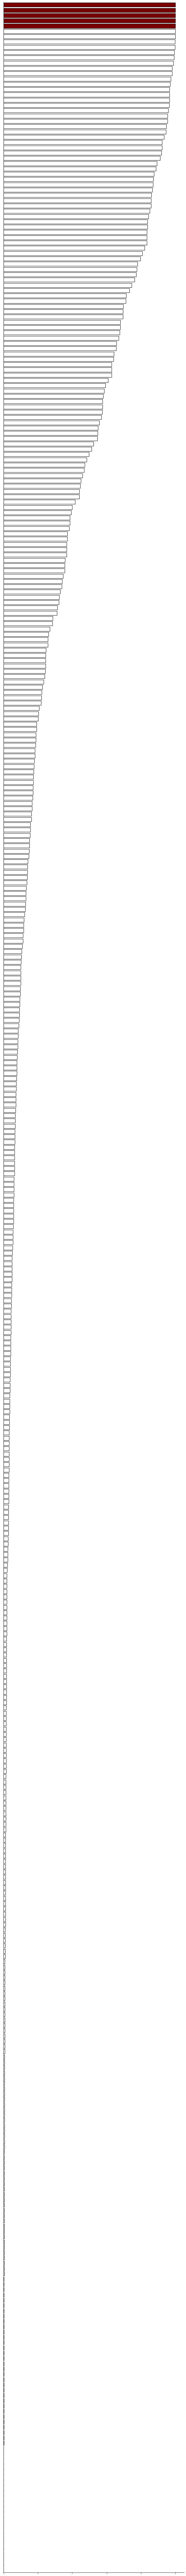

In [40]:
top_num1=5
o=np.argsort(count)[::-1]
amt=count[o].shape[0]
fig_height = max(8, amt * 0.3) 
fig,ax=plt.subplots(figsize=(10,fig_height))
positions=np.arange(len(count))
color_bar=np.full(amt,'#FFFFFF')
color_bar[:top_num1]='#780000'
ax.barh(positions,count[o],color=color_bar,edgecolor='k');
# ax.set_yticks(positions);
# ax.set_yticklabels(val[o]);
ax.set_yticks([]);
ax.set_xticklabels([])
fig.gca().invert_yaxis();
ax.set_ylim(amt - 0.5, -0.5);
ax.tick_params(axis='y',labelsize=20) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'model_counts.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


In [41]:
df=pd.DataFrame({ 'train':model_set['train_acc'],'test':model_set['test_acc'],'null':model_set['null_scores'],'total':np.asarray(model_set['total_scores']),'total null':np.asarray(model_set['total_null']) })

In [42]:
print(np.mean(model_set['train_acc']))
print(np.mean(model_set['test_acc']))
print(np.mean(model_set['null_scores']))
print(np.mean(model_set['total_scores']))
print(np.mean(model_set['total_null']))

0.9928608414239484
0.6332179487179487
0.32974358974358975
0.49278734858681017
0.3332449528936743


In [43]:
TT1 = scipy.stats.ttest_ind(np.asarray(model_set['train_acc']), np.asarray(model_set['test_acc']))
TT2 = scipy.stats.ttest_ind(model_set['null_scores'], model_set['test_acc'])
TT3 = scipy.stats.ttest_ind(model_set['null_scores'], model_set['train_acc'])
TT4 = scipy.stats.ttest_ind(model_set['null_scores'], model_set['total_scores'])
TT5 = scipy.stats.ttest_ind(model_set['total_null'], model_set['total_scores'])

In [44]:
print(TT1)
print(TT2)
print(TT3)
print(TT4)
print(TT5)

Ttest_indResult(statistic=232.75588640934726, pvalue=0.0)
Ttest_indResult(statistic=-136.75194748599097, pvalue=0.0)
Ttest_indResult(statistic=-414.0362780464294, pvalue=0.0)
Ttest_indResult(statistic=-100.48601669335999, pvalue=0.0)
Ttest_indResult(statistic=-263.34710843574913, pvalue=0.0)


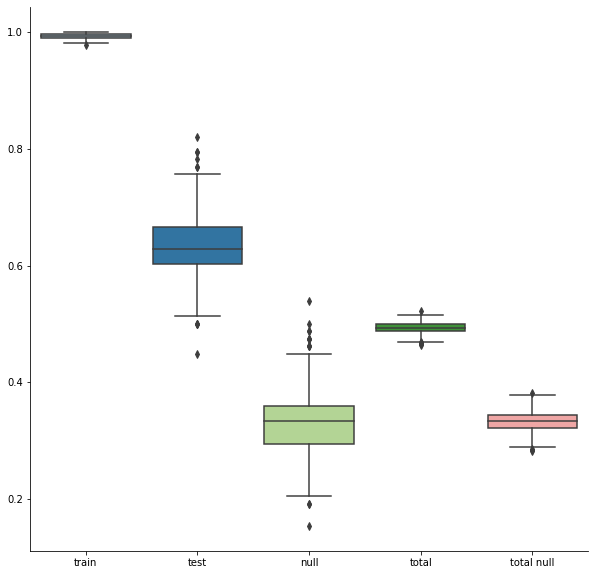

In [45]:
fig,ax=plt.subplots(figsize=(10,10))
sns.boxplot(data=df,ax=ax, palette='Paired')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.set_xticklabels([])
# ax.set_yticklabels([])
# plt.text(0.5, max(df['null_scores'])*1.05, '****', 
#          ha='center', fontsize=20)
# ax.set_ylim(0,1)
# plt.savefig(os.path.join(save_dir,'model_accuracyscores.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'model_accuracyscores.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
plt.show()

In [46]:
y_predict_final=np.hstack(model_set['y_predict'])
y_idxs_final=np.hstack(model_set['y_idx'])

In [47]:
from sklearn.metrics import classification_report, confusion_matrix

# y_pred = rf.predict(X[test_indices])
print("\nTest Set Classification Report:")
print(classification_report(y_predict_final, y_idxs_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_predict_final, y_idxs_final))


Test Set Classification Report:
              precision    recall  f1-score   support

         dec       0.77      0.69      0.73     28939
        flat       0.53      0.54      0.54     24823
         inc       0.59      0.66      0.63     24238

    accuracy                           0.63     78000
   macro avg       0.63      0.63      0.63     78000
weighted avg       0.64      0.63      0.64     78000


Confusion Matrix:
[[20025  4692  4222]
 [ 4715 13348  6760]
 [ 1260  6960 16018]]


In [48]:
full_pred=np.hstack(model_set['pred'])
full_behave=np.vstack(model_set['behave'])

In [49]:
behavior_colors={
    'inc': '#FC00B9',
    'dec': '#17D4DE',
    'flat': '#000000',
    'non': '#727272',
    'un':'orange'
}

In [50]:
scatter_colors=[]
for event in full_pred:
    scatter_colors.append(behavior_colors[event])
scatter_colors=np.asarray(scatter_colors)

In [51]:
# predictions_without=predictions[~np.isin(np.arange(np.shape(predictions)[0]),train_indices)]
# behave_without=behave[~np.isin(np.arange(np.shape(behave)[0]),train_indices)]
# color_without=scatter_colors[~np.isin(np.arange(np.shape(scatter_colors)[0]),train_indices)]

In [52]:
full_behave.shape

(1598000, 2)

In [53]:
total_events_behave['226']['fv'].shape

(198, 2)

In [54]:
uc_events=[]
for fly in total_events_behave:
    bool_lab=total_events_behave[fly]['label']=='non'
    vels=total_events_behave[fly]['fv'][bool_lab]
    uc_events.append(vels)
uc_events=np.vstack(uc_events)
print(uc_events.shape)

(373, 2)


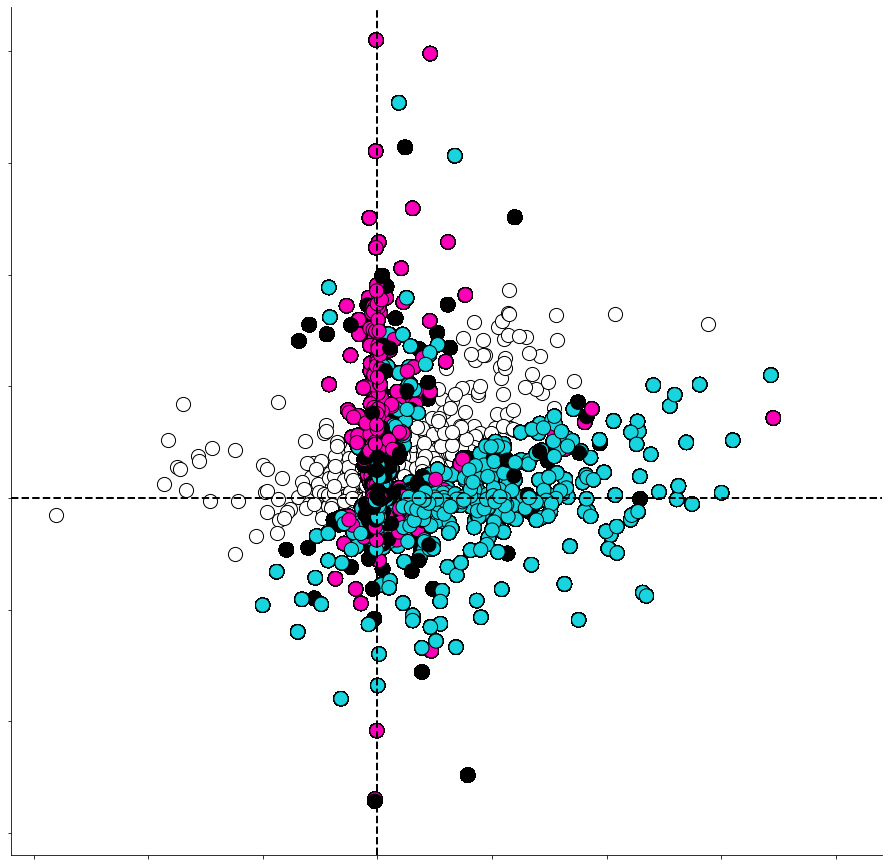

In [55]:
fig = plt.figure(figsize=(20, 20))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                      hspace=0.05, wspace=0.05)
ax_main = fig.add_subplot(gs[1, 0])
# plt.scatter(total_pre, total_post);
behavior_set=full_behave
pred_set=full_pred
ax_main.scatter(np.asarray(uc_events)[:,0], np.asarray(uc_events)[:,1], s=200,color='w',edgecolor='k',rasterized=True);    
ax_main.scatter(np.asarray(behavior_set)[:,0], np.asarray(behavior_set)[:,1], s=200,color=scatter_colors,edgecolor='k',rasterized=True);
        
plt.axvline(0,color='k',linestyle='--',lw=2);
plt.axhline(0,color='k',linestyle='--',lw=2);
# plt.legend();
# ax_main.set_xlabel('Avg velocity 50ms before stim');
# ax_main.set_ylabel('Avg velocity 50ms before end of stim');
ax_main.spines['top'].set_visible(False)
ax_main.spines['right'].set_visible(False)
ax_main.set_xlim((-8,11))
ax_main.set_ylim((-8,11))
# ax_main.tick_params(axis='y',labelsize=20)
# ax_main.tick_params(axis='x',labelsize=20)
ax_main.set_xticklabels([])
ax_main.set_yticklabels([])
# order=['flat','inc','dec'][::-1]
# ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
# for b in order:
#     x=np.asarray(behavior_set)[:,0][pred_set==b]
#     ax_top.hist(x, bins=40, color=behavior_colors[b], alpha=0.7,rasterized=True, density=True)
# ax_top.tick_params(labelbottom=False)
# # ax_top.set_yticks([])
# # ax_top.set_xticks([])
# # ax_top.set_ylabel('De')
# ax_top.spines['top'].set_visible(False)
# ax_top.spines['right'].set_visible(False)
# ax_top.spines['left'].set_visible(False)
# ax_top.spines['bottom'].set_visible(False)



# ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)
# for b in order:
#     y=np.asarray(behavior_set)[:,1][pred_set==b]
#     ax_right.hist(y, bins=40, color=behavior_colors[b], alpha=0.7, orientation='horizontal', rasterized=True,density=True)
# ax_right.tick_params(labelleft=False)
# # ax_right.set_yticks([])
# # ax_right.set_xticks([])
# # ax_right.set_xlabel('Count')
# ax_right.spines['top'].set_visible(False)
# ax_right.spines['right'].set_visible(False)
# ax_right.spines['bottom'].set_visible(False)
# ax_right.spines['left'].set_visible(False)
# plt.rcParams['path.simplify'] = True
# plt.rcParams['path.simplify_threshold'] = 1.0
# plt.rcParams['svg.fonttype'] = 'none'
# plt.savefig(os.path.join(save_dir,'model_scatter.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,'model_scatter.png'), dpi=300, bbox_inches='tight', format="png", transparent=True)
# svgz_path = os.path.join(save_dir, 'model_scatter.svgz')
# with gzip.open(svgz_path, 'wb', compresslevel=9) as f:
#     plt.savefig(f, dpi=300, bbox_inches='tight', format='svg', transparent=True)
plt.show()


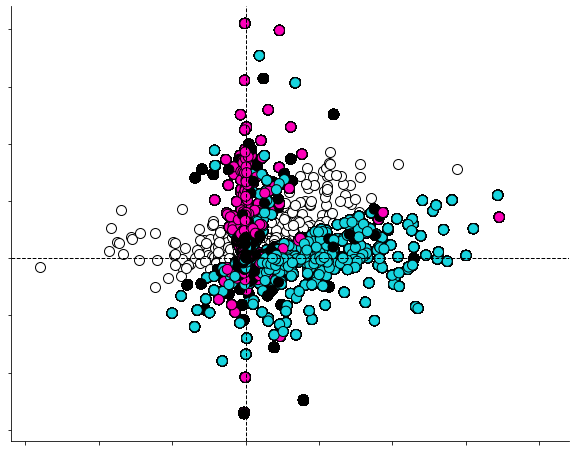

In [56]:
fig,ax=plt.subplots(figsize=(10, 8))
# plt.scatter(total_pre, total_post);
behavior_set=full_behave
pred_set=full_pred

ax.scatter(np.asarray(uc_events)[:,0], np.asarray(uc_events)[:,1], s=100,color='w',edgecolor='k');    
ax.scatter(np.asarray(behavior_set)[:,0], np.asarray(behavior_set)[:,1], s=100,color=scatter_colors,edgecolor='k');
ax.spines['top'].set_visible(False);
ax.spines['right'].set_visible(False);
ax.set_xticklabels([]);
ax.set_yticklabels([]);
ax.set_xlim(-8,11)
ax.set_ylim(-8,11)
plt.axvline(0,color='k',linestyle='--',lw=1);
plt.axhline(0,color='k',linestyle='--',lw=1);
# plt.savefig(os.path.join(save_dir,'model_scatter.png'), dpi=300, bbox_inches='tight', format="png", transparent=True)

In [57]:
np.shape(full_behave)

(1598000, 2)

Text(0, 0.5, '')

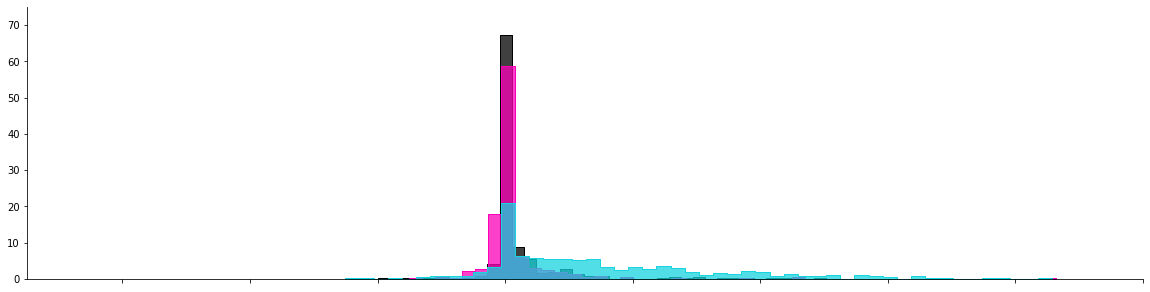

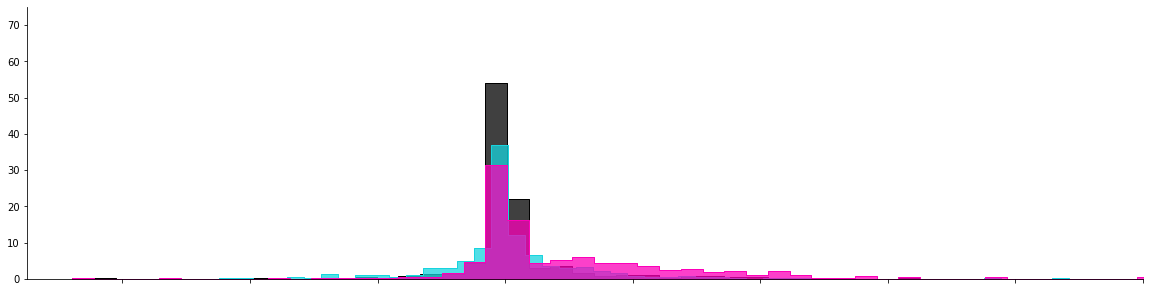

In [58]:
fig,ax = plt.subplots(figsize=(20, 5))
order=['dec','inc','flat'][::-1]
behavior_set=full_behave
pred_set=full_pred
for b in order:
    x=np.asarray(behavior_set)[:,0][pred_set==b]
    sns.histplot(x, bins=50, color=behavior_colors[b], element="step",
    stat="percent", common_norm=False)
ax.set_xlim(-7.5,10)
ax.set_ylim(0,75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.set_ylim(0,3)
# ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_ylabel('')
# plt.savefig(os.path.join(save_dir,f'model_hist_before.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

order=['inc','dec','flat'][::-1]
fig,ax = plt.subplots(figsize=(20, 5))
for b in order:
    y=np.asarray(behavior_set)[:,1][pred_set==b]
    sns.histplot(y, bins=50, color=behavior_colors[b], element="step",
    stat="percent", common_norm=False)
ax.set_xlim(-7.5,10)
ax.set_ylim(0,75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.set_ylim(0,3)
# ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_ylabel('')
# plt.savefig(os.path.join(save_dir,f'model_hist_during.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


In [59]:
cmaps_beahve={
    'inc': matplotlib.colors.LinearSegmentedColormap.from_list('custom', ['w','#FC00B9']),
    'dec': matplotlib.colors.LinearSegmentedColormap.from_list('custom', ['w','#17D4DE']),
    'flat': matplotlib.colors.LinearSegmentedColormap.from_list('custom', ['w','#000000']),
    'non': matplotlib.colors.LinearSegmentedColormap.from_list('custom', ['w','#727272']),
}

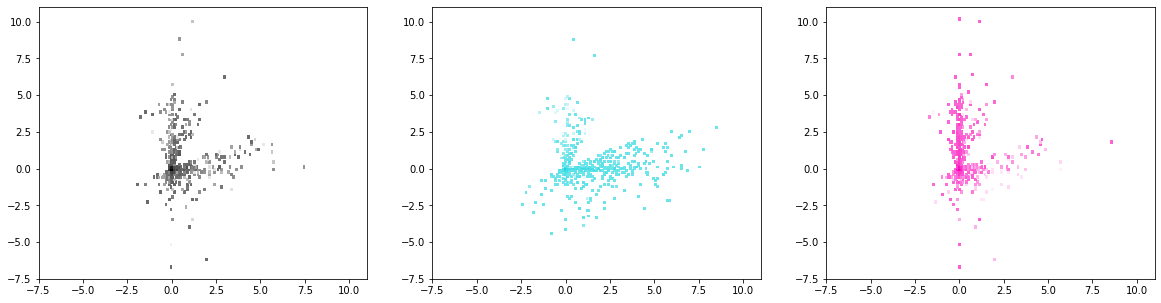

In [60]:
fig,ax = plt.subplots(1,3,figsize=(20, 5))
order=['inc','dec','flat'][::-1]
for i,b in enumerate(order):
    y=np.asarray(behavior_set)[:,1][pred_set==b]
    x=np.asarray(behavior_set)[:,0][pred_set==b]
    ax[i].hist2d(x, y,bins=100,cmap=cmaps_beahve[b],norm=colors.LogNorm())
    ax[i].set_ylim(-7.5,11)
    ax[i].set_xlim(-7.5,11)

In [61]:
print(f'inc: {(np.count_nonzero(full_pred=="inc")/np.shape(full_pred)[0])*100}')
print(f'dec: {(np.count_nonzero(full_pred=="dec")/np.shape(full_pred)[0])*100}')
print(f'flat: {(np.count_nonzero(full_pred=="flat")/np.shape(full_pred)[0])*100}')
pie={'inc':np.count_nonzero(full_pred=="inc"),'dec':np.count_nonzero(full_pred=="dec"),'flat':np.count_nonzero(full_pred=="flat")}

inc: 28.853254067584484
dec: 35.31858573216521
flat: 35.828160200250316


In [62]:
def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f"{pct:.1f}%"


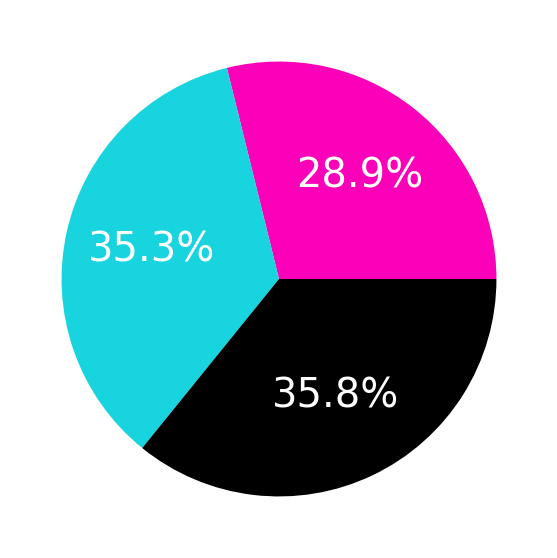

In [63]:
pie_col=['#FC00B9','#17D4DE','#000000']
fig, ax = plt.subplots(figsize=(10,10))
ax.pie(x=list(pie.values()), colors=pie_col,autopct=lambda pct: func(pct, list(pie.values())),textprops=dict(color="w",size=40));
# plt.savefig(os.path.join(save_dir,'model_pie.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'model_pie.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)



In [64]:
ids,counts=np.unique(model_set['top_100'], return_counts=True)
top_ids=ids[np.argsort(counts)[::-1]][:100]
top_counts=counts[np.argsort(counts)[::-1]][:100]

In [65]:
np.asarray(model_set['top_import']).shape

(1000, 100)

In [66]:
top_100=np.asarray(model_set['top_100'])
top_import=np.asarray(model_set['top_import'])
new_importances={}
for i in top_ids:
    new_importances[i]=[]
for i in top_ids:
#     print(i)
    for j,x in enumerate(top_import):
#         print(x)
        importance_vals=x
        val=importance_vals[np.isin(top_100[j,:],i)]
        new_importances[i].append(val)
    new_importances[i]=np.hstack(new_importances[i])

In [67]:
top_importances_final=[]
for ids in new_importances:
    top_importances_final.append(np.mean(new_importances[ids]))
top_importances_final=np.asarray(top_importances_final)

In [68]:
order=np.argsort(top_importances_final)[::-1]
ids=top_ids[order]
count=top_counts[order]
importance=top_importances_final[order]

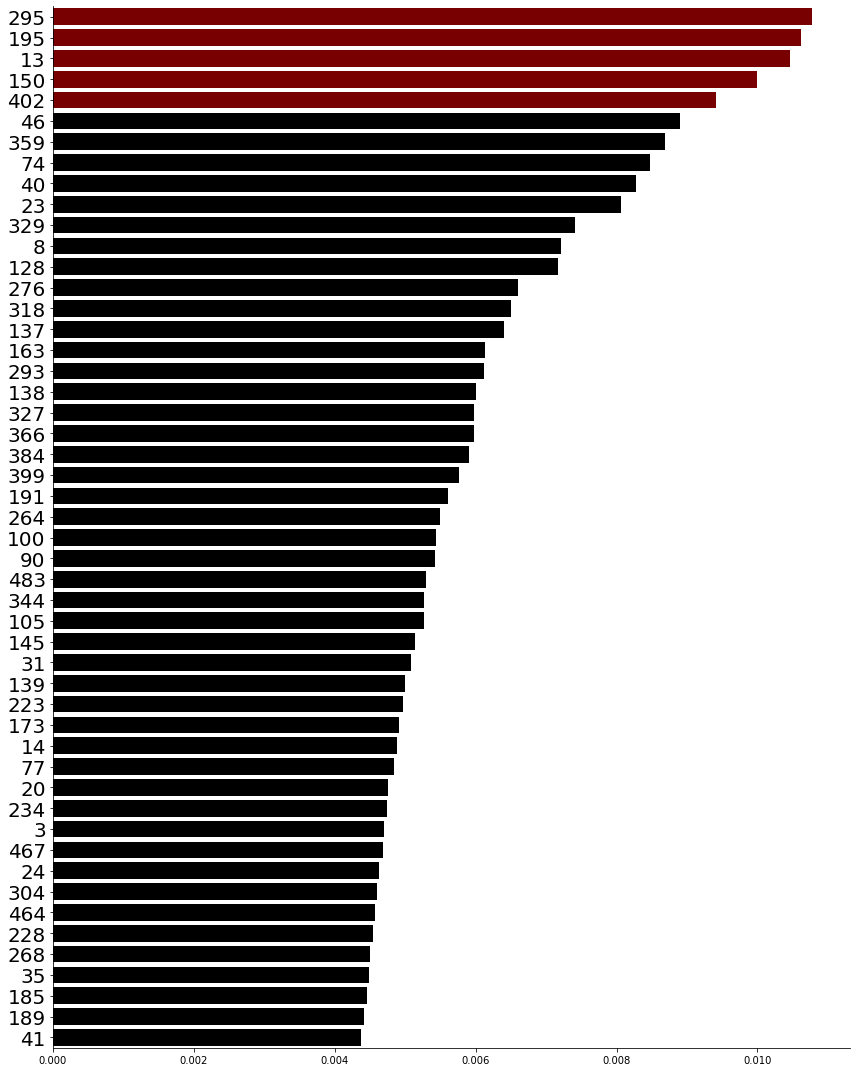

In [69]:
# Plot feature importances
amt=50
top_num1=5
top_num2=10
fig_height = max(8, amt * 0.3) 
fig,ax=plt.subplots(figsize=(12, fig_height))
positions = np.arange(amt)
color_bar=np.full(amt,'#000000')
color_bar[:top_num1]='#780000'
# color_bar[top_num1:top_num2]='#003049'
# top = importance_df.head(amt)
ax.barh(positions,importance[:amt],color=color_bar)
ax.set_yticks(positions)
ax.set_yticklabels(ids[:amt])
# ax.set_xticklabels([])
ax.tick_params(axis='y',labelsize=20) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.xlabel('Importance')
# plt.ylabel('Cluster ID')
# plt.title(f'Top {amt} Most Important Clusters')
fig.gca().invert_yaxis()
ax.set_ylim(amt - 0.5, -0.5)

# plt.savefig(os.path.join(save_dir,f'top{amt}_cluster_bar.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'top{amt}_cluster_bar.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
plt.tight_layout()
plt.show()

In [70]:
def create_dark_to_color_cmap(color):
    """Create colormap from black to specified color"""
    return matplotlib.colors.LinearSegmentedColormap.from_list('custom', ['w','#FFADAD',color,color,color]) # '#70CDFF'

In [71]:
load_file = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/20210817_luke_mean_highres.nii"
anat_high_res = np.asarray(nib.load(load_file).get_fdata().squeeze(), dtype='float32')
anat_high_res.shape
anat_uint=anat_high_res.astype('uint8')

In [72]:
atlas_path = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/jfrc_2018_rois_improve_reorient_transformed_nearest_neighbor.nii"
atlas = np.asarray(nib.load(atlas_path).get_fdata().squeeze(), dtype='float32')
atlas = ants.from_numpy(atlas)
atlas.set_spacing((.76,.76,.76))
#atlas = ants.resample_image(atlas,(2,2,2),use_voxels=False)
atlas = ants.resample_image(atlas,(.5,.5,.5),use_voxels=False)
print(atlas.shape)
atlas = atlas.numpy()
atlas_int = atlas.astype('uint8')


(1256, 584, 363)


In [73]:
nx,ny,nz=atlas.shape
ox,oy,oz=giant_labels_anat.shape
# scale_factors = (nx/ox, ny/oy, nz/oz)
scale_factors = (ox/nx, oy/ny, oz/nz)
# Resample using zoom with cubic interpolation (order=3)
anat_lowres = zoom(anat_high_res, scale_factors, order=3)
atlas_lowres = zoom(atlas_int, scale_factors, order=3)

In [74]:
print(anat_lowres.shape)
# atlas_int = anat_lowres.astype('uint8')

(314, 146, 91)


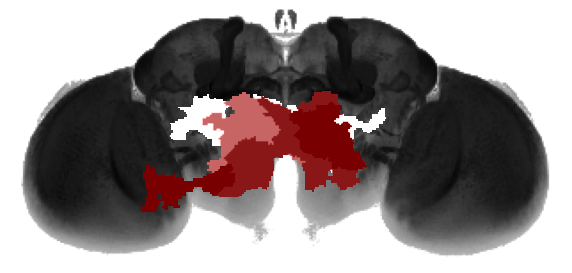

In [75]:
amt=5
# print(np.shape(cluster_importances[b]))
fig,ax=plt.subplots(figsize=(10,10))
plt.imshow(np.max(anat_lowres, axis=-1).T,cmap='gray_r');
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,ids[:amt]),giant_labels_anat,np.nan)
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap=create_dark_to_color_cmap('#780000'))
ax.axis('off');
# plt.savefig(os.path.join(save_dir,f'top{amt}_cluster_loc.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'top{amt}_cluster_loc.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


In [76]:
roi_atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [77]:
def explode_plot(brain,vmax,explosion_rois,roi_masks,roi_contours,tp=None,cmap='seismic'):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    if tp==None:
        data_to_plot = brain[:,:,::-1]
    else:
        data_to_plot = brain[tp][:,:,::-1]
    vmax =vmax #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap=cmap, diverging=False)#'hot')
    return explosion_map

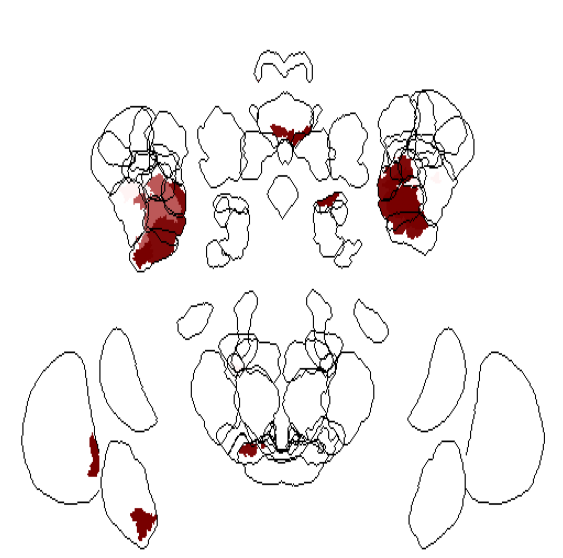

In [78]:
ax_as=1.5
vmax=np.nanmax(labels_anat_sub_total)
fig,axs=plt.subplots(figsize=(10,10))
temp=explode_plot(np.nan_to_num(labels_anat_sub_total),vmax,explosion_rois,roi_masks,roi_contours,cmap=create_dark_to_color_cmap('#780000'))
brain=axs.imshow(temp[170:,:]) #this was made with cmap=hot
axs.axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
axs.set_aspect(ax_as)
# plt.savefig(os.path.join(save_dir,f'top{amt}_explosion.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'top{amt}_explosion.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)


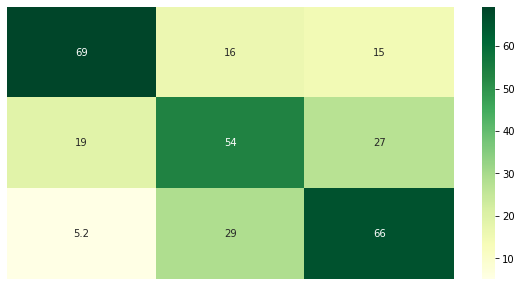

In [79]:
be=['dec','flat','inc']
cm = confusion_matrix(y_predict_final, y_idxs_final)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cm_percent, ax=ax, annot=True, cmap='YlGn');
ax.xaxis.set_ticks([]);
ax.yaxis.set_ticks([]);
# _ = ax.set_title(
#     f"Confusion Matrix for {rf.__class__.__name__}"
# )

# plt.savefig(os.path.join(save_dir,f'confusion_matrix_{rf.__class__.__name__}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'onfusion_matrix_randomforest.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
